# Análisis Exploratorio de Datos (EDA) - GTFS Histórico Cleaned

## Objetivo
Realizar un análisis descriptivo y exploratorio del dataset de retrasos del metro NYC después de la transformación cleaned.
Este análisis permite entender las características principales de las variables y sus relaciones, especialmente con la variable objetivo (delay_seconds).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✓ Setup completado")

✓ Setup completado


In [ ]:
from src.common.minio_client import download_df_parquet

access_key = os.getenv("MINIO_ACCESS_KEY")
secret_key = os.getenv("MINIO_SECRET_KEY")

if not access_key or not secret_key:
    raise ValueError("Las variables de entorno MINIO_ACCESS_KEY y MINIO_SECRET_KEY no están definidas")

# Descargar datos
START_DATE = "2025-08-10"
END_DATE = "2025-09-16"

dates = pd.date_range(start=START_DATE, end=END_DATE).strftime("%Y-%m-%d").tolist()
dfs = []

for SERVICE_DATE in dates:
    sched = download_df_parquet(access_key, secret_key, f"grupo5/cleaned/gtfs_clean_scheduled/date={SERVICE_DATE}/gtfs_scheduled_{SERVICE_DATE}.parquet")
    unsched = download_df_parquet(access_key, secret_key, f"grupo5/cleaned/gtfs_clean_unscheduled/date={SERVICE_DATE}/gtfs_unscheduled_{SERVICE_DATE}.parquet")
    sched['dataset_type'] = 'scheduled'
    unsched['dataset_type'] = 'unscheduled'
    dfs.extend([sched, unsched])

df_full = pd.concat(dfs, ignore_index=True)
split_info = df_full['dataset_type'].value_counts()

print(f"✓ Datos cargados: {len(df_full):,} registros")
print(f"  - Scheduled: {split_info.get('scheduled', 0):,}")
print(f"  - Unscheduled: {split_info.get('unscheduled', 0):,}")

✓ Datos cargados: 7,744,391 registros
  - Scheduled: 5,815,190
  - Unscheduled: 1,929,201


## Sección 1: Análisis General

In [3]:
print("="*70)
print("1.1 DIMENSIONES")
print("="*70)
print(f"Shape: {df_full.shape}")
print(f"Memoria: {df_full.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

dtype_summary = pd.DataFrame({
    'Columna': df_full.columns,
    'Tipo': df_full.dtypes.values,
    'No Nulos': df_full.count().values,
    '% Nulos': (df_full.isnull().sum().values / len(df_full) * 100).round(2)
})
print("\n" + dtype_summary.to_string(index=False))

1.1 DIMENSIONES
Shape: (7744391, 36)
Memoria: 2859.51 MB

                Columna    Tipo  No Nulos  % Nulos
               trip_uid  string   7744391     0.00
              match_key  string   7744391     0.00
               route_id  string   5815190    24.91
                stop_id  string   7744391     0.00
         is_unscheduled    bool   7744391     0.00
      scheduled_seconds float64   5815190    24.91
         actual_seconds float64   7655991     1.14
          delay_seconds float64   5726790    26.05
          delay_minutes float64   5726790    26.05
           service_date     str   7744391     0.00
                   hour   Int64   7744391     0.00
               hour_sin float64   7744391     0.00
               hour_cos float64   7744391     0.00
                    dow   Int64   7744391     0.00
             is_weekend   Int64   7744391     0.00
         scheduled_time     str   5815190    24.91
            actual_time     str   7655991     1.14
         lagged_delay_1 

## Sección 2: Variable Objetivo (delay_seconds)


2.1 ESTADÍSTICAS DELAY_SECONDS
count    5.726790e+06
mean     7.671612e+01
std      3.029554e+02
min     -6.420000e+03
25%     -4.700000e+01
50%      2.100000e+01
75%      1.400000e+02
90%      3.330000e+02
95%      5.050000e+02
99%      1.065000e+03
max      8.999000e+03
Name: delay_seconds, dtype: float64


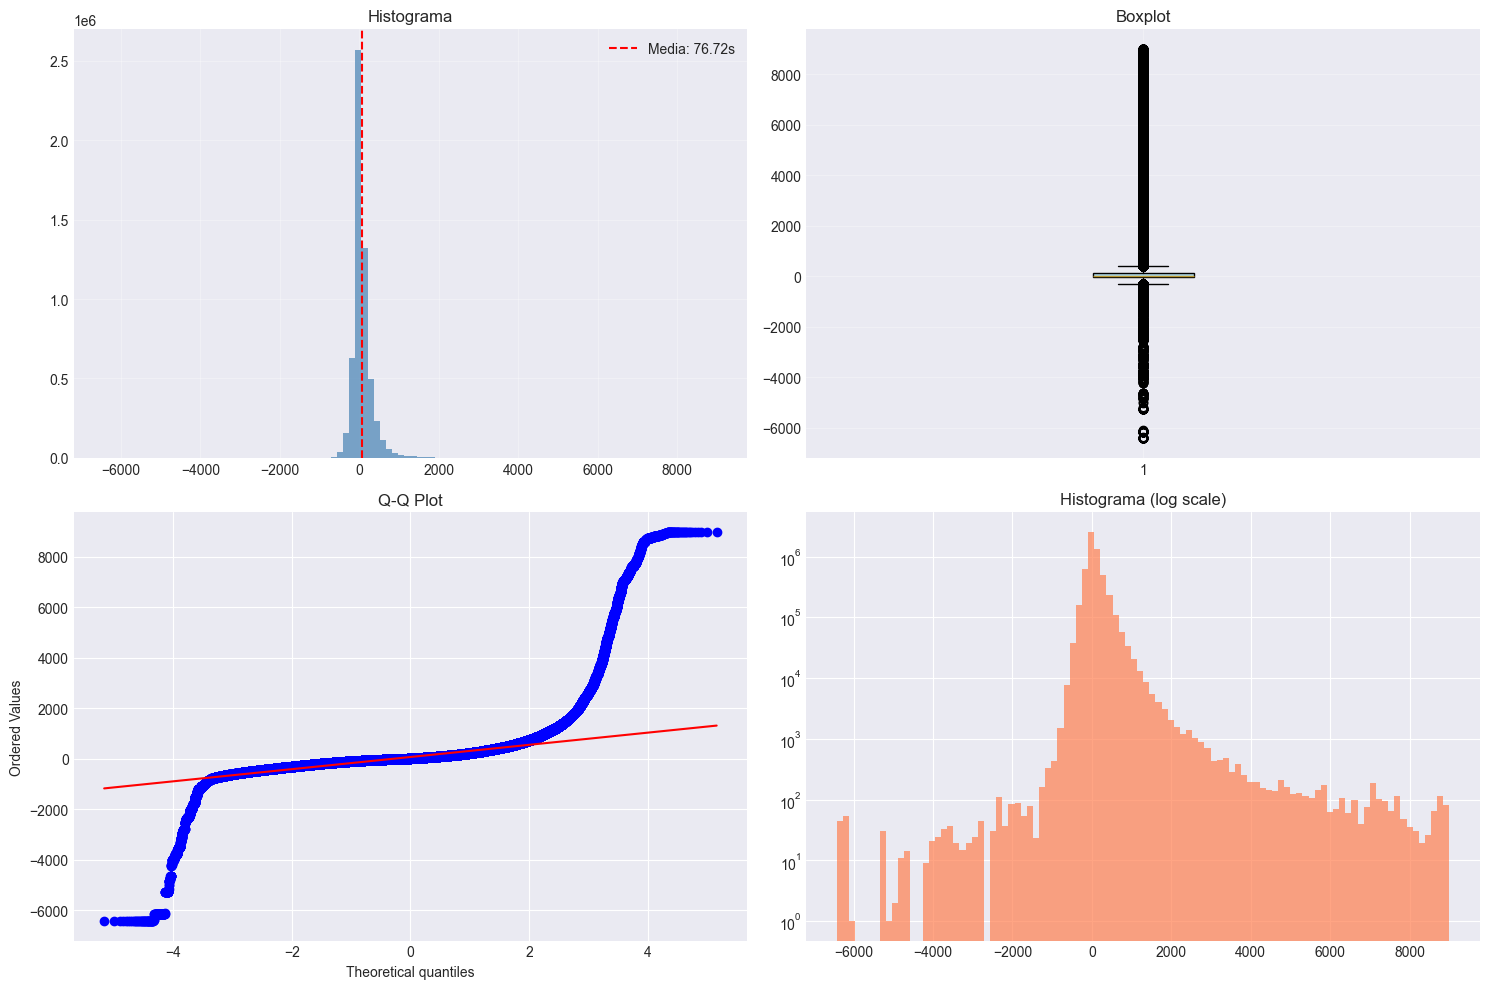

In [4]:
print("\n" + "="*70)
print("2.1 ESTADÍSTICAS DELAY_SECONDS")
print("="*70)

print(df_full['delay_seconds'].describe(percentiles=[0.25, 0.5, 0.75, 0.90, 0.95, 0.99]))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].hist(df_full['delay_seconds'].dropna(), bins=100, color='steelblue', alpha=0.7)
axes[0, 0].axvline(df_full['delay_seconds'].mean(), color='red', linestyle='--', label=f"Media: {df_full['delay_seconds'].mean():.2f}s")
axes[0, 0].set_title('Histograma')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

bp = axes[0, 1].boxplot(df_full['delay_seconds'].dropna(), patch_artist=True)
for patch in bp['boxes']: patch.set_facecolor('lightblue')
axes[0, 1].set_title('Boxplot')
axes[0, 1].grid(alpha=0.3)

from scipy import stats
stats.probplot(df_full['delay_seconds'].dropna(), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')

axes[1, 1].hist(df_full['delay_seconds'].dropna(), bins=100, color='coral', alpha=0.7)
axes[1, 1].set_yscale('log')
axes[1, 1].set_title('Histograma (log scale)')

plt.tight_layout()
plt.show()

In [5]:
# Análisis de ceros y extremos
zeros = len(df_full[df_full['delay_seconds'] == 0])
non_zeros = len(df_full[df_full['delay_seconds'] != 0])

print(f"Ceros: {zeros:,} ({zeros/len(df_full)*100:.2f}%)")
print(f"No ceros: {non_zeros:,} ({non_zeros/len(df_full)*100:.2f}%)")

percentiles = [0.90, 0.95, 0.99]
delay_nonnull = df_full['delay_seconds'].dropna()
for p in percentiles:
    val = delay_nonnull.quantile(p)
    count = len(df_full[df_full['delay_seconds'] > val])
    print(f"P{int(p*100)}: {val:.2f}s - {count:,} registros")

Ceros: 178,661 (2.31%)
No ceros: 7,565,730 (97.69%)
P90: 333.00s - 571,443 registros
P95: 505.00s - 285,159 registros
P99: 1065.00s - 57,239 registros


## Sección 3: Patrones Temporales


3.1 DELAY POR HORA
        mean  median     std   count
hour                                
0     214.98   107.0  388.60  103931
1     243.62   122.0  379.42   83515
2     242.76   112.0  401.57   89126
3     188.11    75.0  378.73   96323
4     115.00    35.0  333.20  104723
5      79.40    27.0  278.59  140178
6      60.63    15.0  287.64  216271
7      35.13     0.0  275.37  294270
8      34.82     0.0  293.07  336647
9      45.83     2.0  320.21  328831
10     68.41    17.0  290.29  298506
11     95.77    35.0  304.07  289005
12     80.57    28.0  263.82  285094
13     55.07    12.0  250.39  287657
14     46.55     6.0  249.40  292080
15     48.14    10.0  245.08  307165
16     55.48    13.0  301.00  334125
17     71.98    19.0  327.57  338638
18     68.83    15.0  323.96  320154
19     59.35    13.0  305.81  302331
20     74.17    28.0  288.64  281488
21     86.12    33.0  274.68  244634
22    104.26    45.0  293.91  196502
23    146.89    67.0  349.92  155596


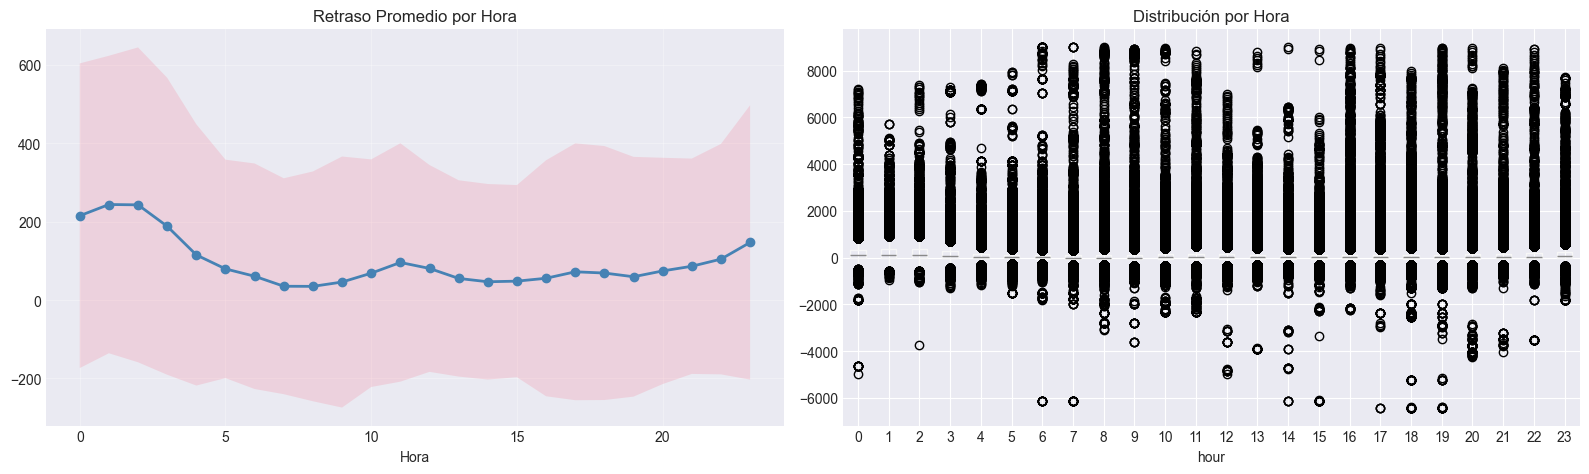

In [6]:
print("\n" + "="*70)
print("3.1 DELAY POR HORA")
print("="*70)

hourly = df_full.groupby('hour')['delay_seconds'].agg(['mean', 'median', 'std', 'count'])
print(hourly.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(hourly.index, hourly['mean'], marker='o', linewidth=2, color='steelblue')
axes[0].fill_between(hourly.index, hourly['mean'] - hourly['std'], hourly['mean'] + hourly['std'], alpha=0.2)
axes[0].set_title('Retraso Promedio por Hora')
axes[0].set_xlabel('Hora')
axes[0].grid(alpha=0.3)

df_full.boxplot(column='delay_seconds', by='hour', ax=axes[1])
axes[1].set_title('Distribución por Hora')
plt.suptitle('')

plt.tight_layout()
plt.show()


3.2 DELAY POR PERÍODO Y DÍA
                 mean    count
period_of_day                 
off_peak       127.61  1496016
morning_peak    42.72  1176019
midday          65.53  1759507
evening_peak    64.00  1295248

Delay por Día:
             mean    count
dow                       
Lunes       63.43   991309
Martes      78.11  1055375
Miércoles   77.67   862125
Jueves      77.28   858091
Viernes     50.08   890027
Sábado     116.80   501467
Domingo    101.34   568396


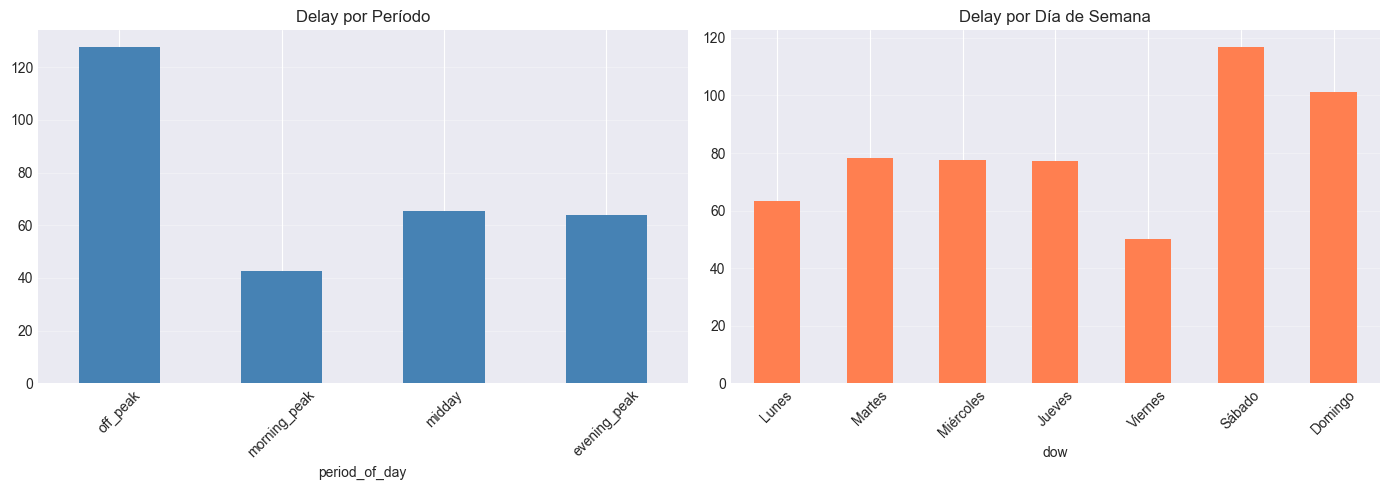

In [7]:
print("\n" + "="*70)
print("3.2 DELAY POR PERÍODO Y DÍA")
print("="*70)

period_order = ['off_peak', 'morning_peak', 'midday', 'evening_peak']
period_delay = df_full.groupby('period_of_day')['delay_seconds'].agg(['mean', 'count']).reindex(period_order)
print(period_delay.round(2))

dow_names = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}
dow_delay = df_full.groupby('dow')['delay_seconds'].agg(['mean', 'count'])
dow_delay.index = dow_delay.index.map(dow_names)
print("\nDelay por Día:")
print(dow_delay.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

period_delay['mean'].plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Delay por Período')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(axis='y', alpha=0.3)

dow_delay['mean'].plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Delay por Día de Semana')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Sección 4: Análisis por Línea (Route)

In [8]:
print("\n" + "="*70)
print("4.1 DELAY POR LÍNEA (ROUTE_ID)")
print("="*70)

route_delay = df_full.groupby('route_id')['delay_seconds'].agg(['count', 'mean', 'std', 'min', 'max'])
route_delay = route_delay.sort_values('mean', ascending=False)
print(route_delay.round(2))
print(f"\nTotal líneas: {len(route_delay)}")


4.1 DELAY POR LÍNEA (ROUTE_ID)
           count    mean     std     min     max
route_id                                        
SI         58549  212.28  471.94  -467.0  8678.0
F         427437  162.17  384.71 -6420.0  8998.0
C         253893  157.55  323.76 -2820.0  8965.0
N         256461  134.82  406.26 -5250.0  8993.0
J         239405  131.45  253.47 -6150.0  8204.0
E         256065  123.91  354.64 -4020.0  8876.0
B         155605  121.59  364.53 -2003.0  8999.0
A         342655   97.84  376.71 -1800.0  8996.0
Q         282695   93.75  273.68 -6145.0  8215.0
Z           6211   81.09  168.28  -433.0  2018.0
FX          3850   80.28  281.51  -729.0  2329.0
FS         23317   78.19  528.76 -3600.0  8944.0
2         494689   75.38  312.85 -5001.0  6449.0
W          90102   73.82  288.86 -3900.0  8938.0
H          28750   67.44  336.28  -770.0  7948.0
G         197274   65.03  206.58 -1050.0  5624.0
R         314253   57.10  287.04 -2370.0  8994.0
1         525238   49.10  175.31 -392

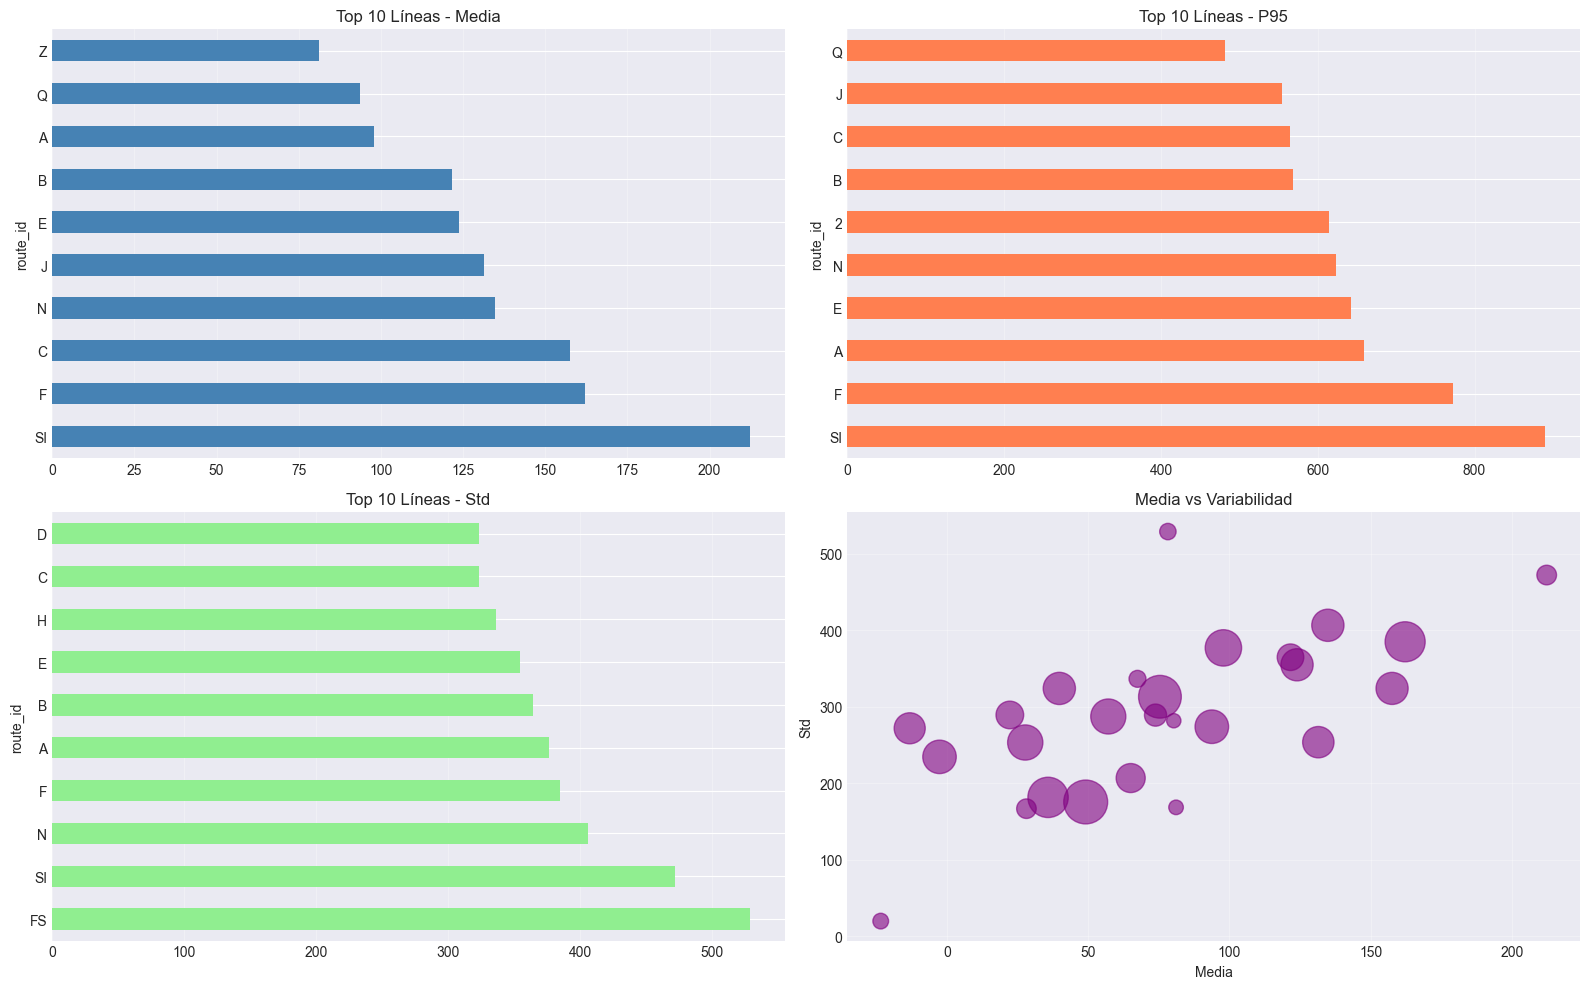

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

top10_mean = route_delay['mean'].nlargest(10)
top10_mean.plot(kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Top 10 Líneas - Media')
axes[0, 0].grid(axis='x', alpha=0.3)

route_p95 = df_full.groupby('route_id')['delay_seconds'].quantile(0.95)
route_p95.nlargest(10).plot(kind='barh', ax=axes[0, 1], color='coral')
axes[0, 1].set_title('Top 10 Líneas - P95')
axes[0, 1].grid(axis='x', alpha=0.3)

route_delay['std'].nlargest(10).plot(kind='barh', ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Top 10 Líneas - Std')
axes[1, 0].grid(axis='x', alpha=0.3)

# Definimos el tamaño mínimo y máximo que queremos ver en la gráfica
tamanio_min = 100
tamanio_max = 1000
# Calculamos tamaños de burbuja
proporcion = route_delay['count'] / route_delay['count'].max()
tamanio_variable = tamanio_min + (proporcion * (tamanio_max - tamanio_min))
axes[1, 1].scatter(route_delay['mean'], route_delay['std'], s=tamanio_variable, alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Media')
axes[1, 1].set_ylabel('Std')
axes[1, 1].set_title('Media vs Variabilidad')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


4.3 INTERACCIÓN: ROUTE × HORA


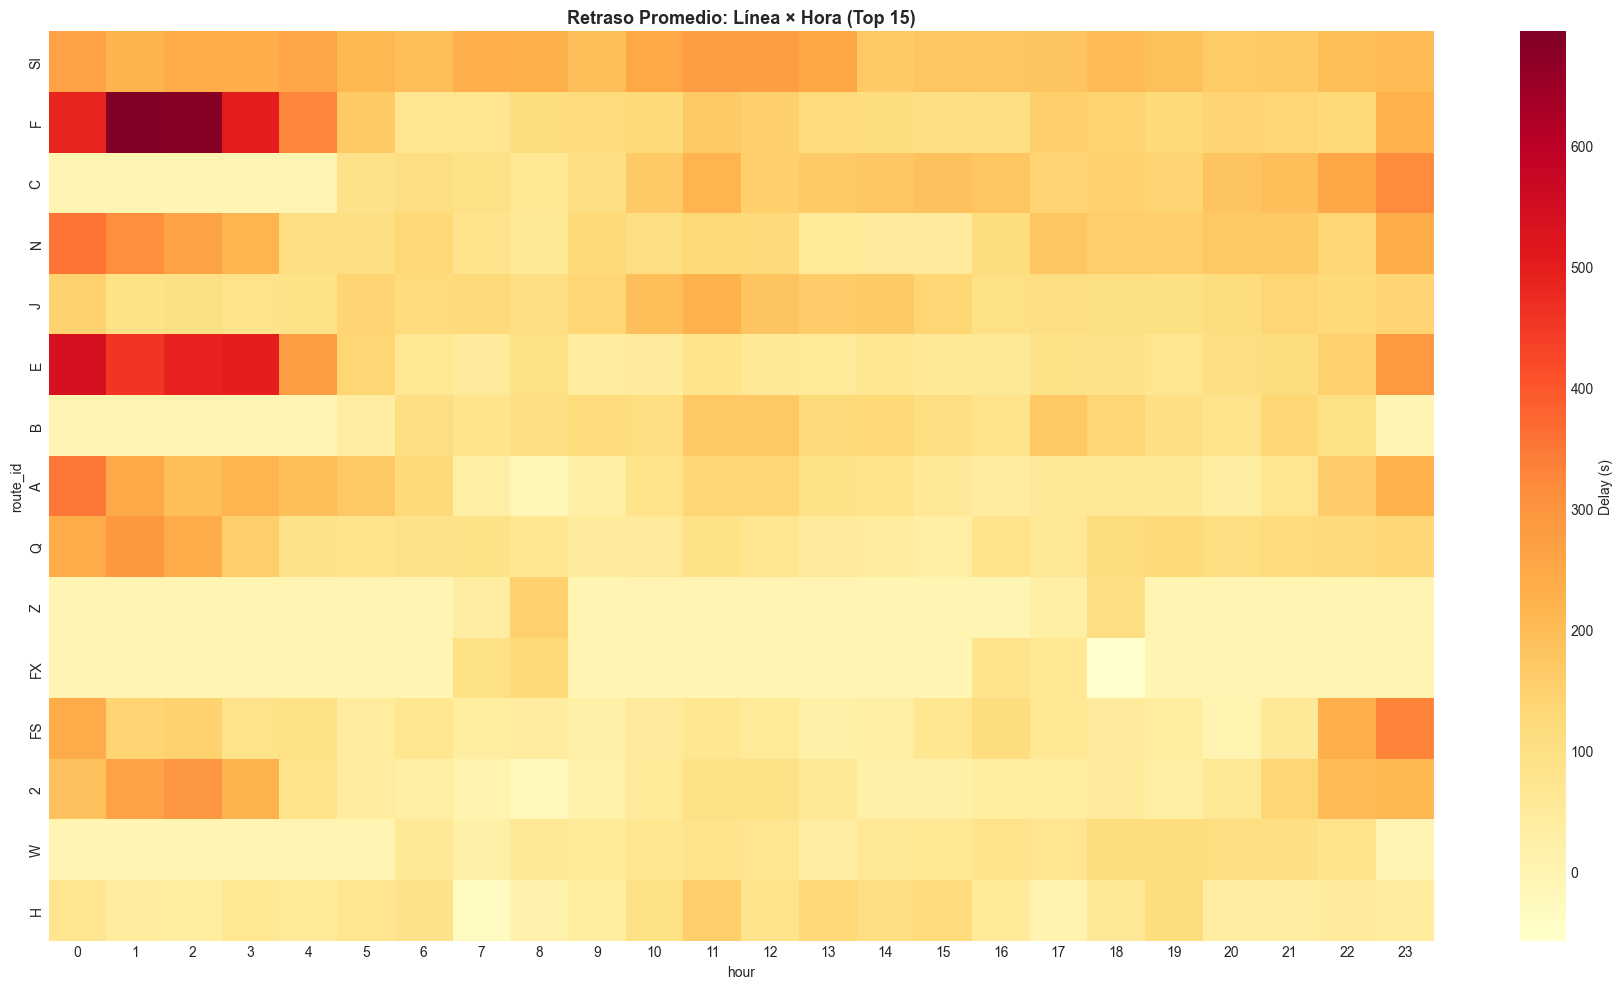


Patrones por Línea:
  SI: Max 279.4s (@11h) | Min 165.5s
  F: Max 694.6s (@1h) | Min 73.4s
  C: Max 320.8s (@23h) | Min 0.0s
  N: Max 354.5s (@0h) | Min 51.3s
  J: Max 226.2s (@11h) | Min 85.5s


In [10]:
# 4.3 Route × Hora heatmap
print("\n" + "="*70)
print("4.3 INTERACCIÓN: ROUTE × HORA")
print("="*70)

route_hour = df_full.groupby(['route_id', 'hour'])['delay_seconds'].mean().unstack(fill_value=0)
top_routes = df_full.groupby('route_id')['delay_seconds'].mean().nlargest(15).index

fig, ax = plt.subplots(figsize=(18, 10))
sns.heatmap(route_hour.loc[top_routes], cmap='YlOrRd', ax=ax, cbar_kws={'label': 'Delay (s)'})
ax.set_title('Retraso Promedio: Línea × Hora (Top 15)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nPatrones por Línea:")
for route in list(top_routes)[:5]:
    delays = route_hour.loc[route]
    print(f"  {route}: Max {delays.max():.1f}s (@{int(delays.idxmax())}h) | Min {delays.min():.1f}s")

## Sección 5: Propagación de Retrasos


5.1 RETRASOS REZAGADOS
       delay_seconds  lagged_delay_1  lagged_delay_2
count     5726790.00      5607057.00      5396148.00
mean           76.72           76.60           75.44
std           302.96          297.13          294.37
min         -6420.00        -6420.00        -6420.00
25%           -47.00          -46.00          -46.00
50%            21.00           22.00           22.00
75%           140.00          140.00          138.00
max          8999.00         8999.00         8998.00

Correlaciones:
                delay_seconds  lagged_delay_1  lagged_delay_2
delay_seconds           1.000           0.956           0.932
lagged_delay_1          0.956           1.000           0.967
lagged_delay_2          0.932           0.967           1.000


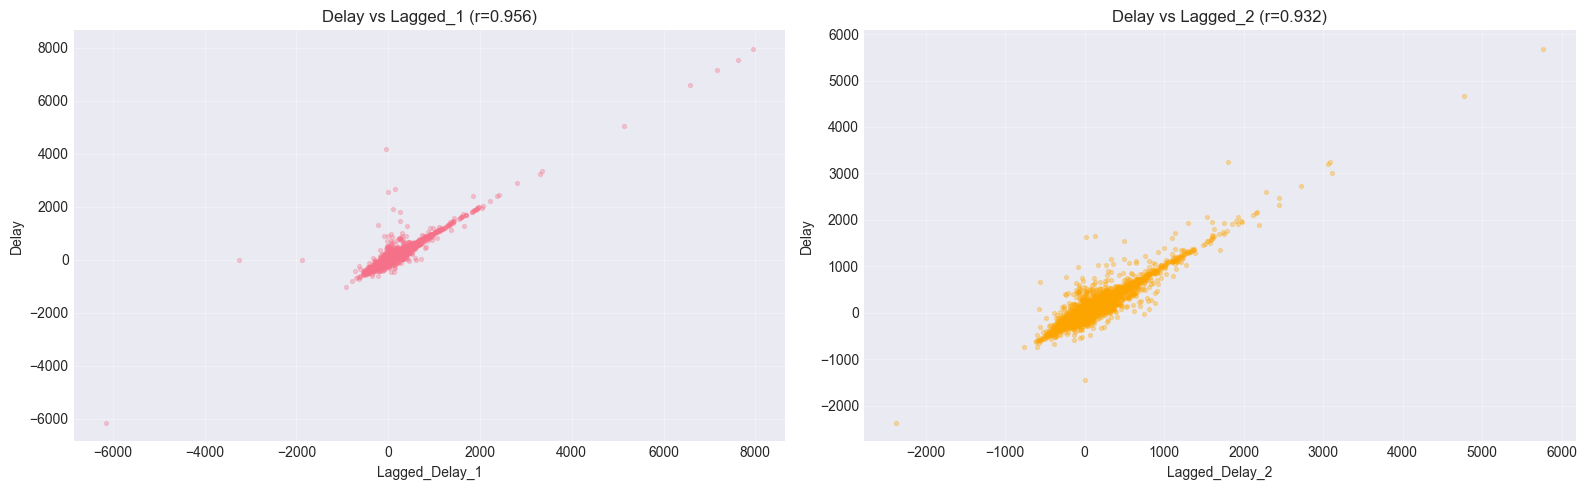

In [11]:
print("\n" + "="*70)
print("5.1 RETRASOS REZAGADOS")
print("="*70)

lagged_stats = pd.DataFrame({
    'delay_seconds': df_full['delay_seconds'].describe(),
    'lagged_delay_1': df_full['lagged_delay_1'].describe(),
    'lagged_delay_2': df_full['lagged_delay_2'].describe()
})
print(lagged_stats.round(2))

delay_cols = ['delay_seconds', 'lagged_delay_1', 'lagged_delay_2']
delay_corr = df_full[delay_cols].corr()
print("\nCorrelaciones:")
print(delay_corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample = df_full.dropna(subset=['delay_seconds', 'lagged_delay_1']).sample(min(8000, len(df_full)))
axes[0].scatter(sample['lagged_delay_1'], sample['delay_seconds'], alpha=0.3, s=8)
axes[0].set_xlabel('Lagged_Delay_1')
axes[0].set_ylabel('Delay')
axes[0].set_title(f'Delay vs Lagged_1 (r={delay_corr.loc["delay_seconds", "lagged_delay_1"]:.3f})')
axes[0].grid(alpha=0.3)

sample2 = df_full.dropna(subset=['delay_seconds', 'lagged_delay_2']).sample(min(8000, len(df_full)))
axes[1].scatter(sample2['lagged_delay_2'], sample2['delay_seconds'], alpha=0.3, s=8, color='orange')
axes[1].set_xlabel('Lagged_Delay_2')
axes[1].set_ylabel('Delay')
axes[1].set_title(f'Delay vs Lagged_2 (r={delay_corr.loc["delay_seconds", "lagged_delay_2"]:.3f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


5.2 ROLLING DELAYS (RUTA + VIAJE)
route_rolling_delay:      0.5574
rolling_mean_delay_trip:  0.9468


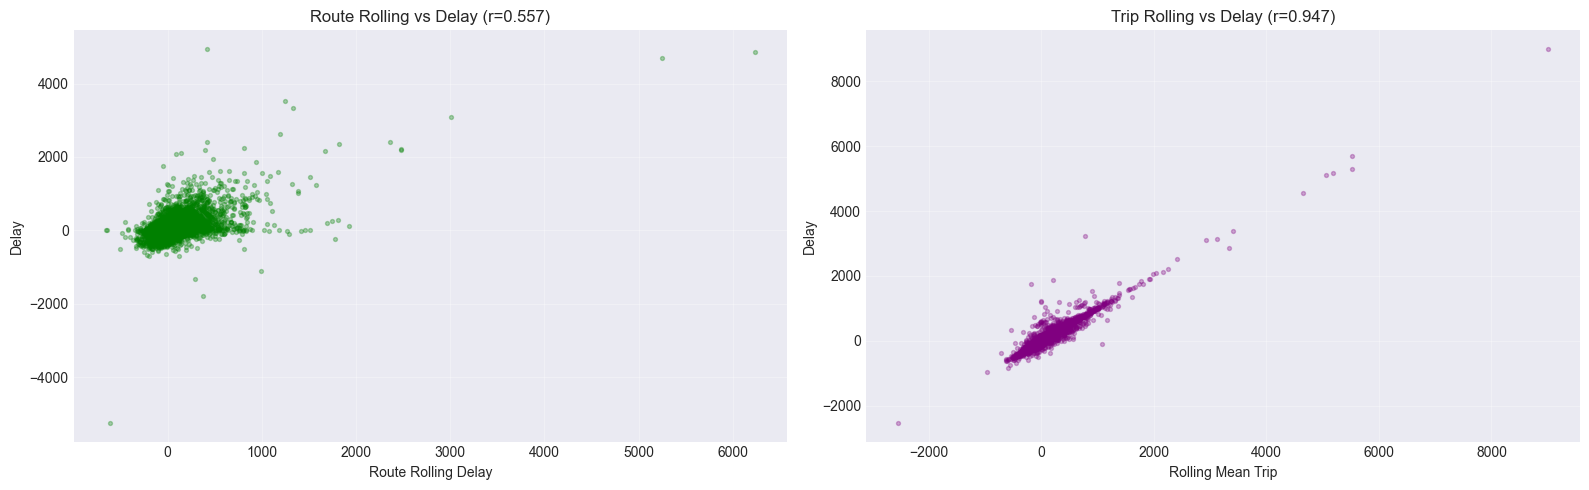

In [12]:
# 5.2 Rolling delays consolidado
print("\n" + "="*70)
print("5.2 ROLLING DELAYS (RUTA + VIAJE)")
print("="*70)

route_roll_corr = df_full['delay_seconds'].corr(df_full['route_rolling_delay'])
trip_roll_corr = df_full['delay_seconds'].corr(df_full['rolling_mean_delay_trip'])

print(f"route_rolling_delay:      {route_roll_corr:.4f}")
print(f"rolling_mean_delay_trip:  {trip_roll_corr:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sample = df_full.dropna(subset=['delay_seconds', 'route_rolling_delay']).sample(min(8000, len(df_full)))
axes[0].scatter(sample['route_rolling_delay'], sample['delay_seconds'], alpha=0.3, s=8, color='green')
axes[0].set_xlabel('Route Rolling Delay')
axes[0].set_ylabel('Delay')
axes[0].set_title(f'Route Rolling vs Delay (r={route_roll_corr:.3f})')
axes[0].grid(alpha=0.3)

sample2 = df_full.dropna(subset=['delay_seconds', 'rolling_mean_delay_trip']).sample(min(8000, len(df_full)))
axes[1].scatter(sample2['rolling_mean_delay_trip'], sample2['delay_seconds'], alpha=0.3, s=8, color='purple')
axes[1].set_xlabel('Rolling Mean Trip')
axes[1].set_ylabel('Delay')
axes[1].set_title(f'Trip Rolling vs Delay (r={trip_roll_corr:.3f})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


5.3 MATRIZ DE CORRELACIÓN
                         delay_seconds  lagged_delay_1  lagged_delay_2  \
delay_seconds                    1.000           0.956           0.932   
lagged_delay_1                   0.956           1.000           0.967   
lagged_delay_2                   0.932           0.967           1.000   
actual_headway_seconds           0.122           0.122           0.130   
headway_ratio                    0.005           0.005           0.005   
route_rolling_delay              0.557           0.578           0.582   
rolling_mean_delay_trip          0.947           0.978           0.984   
hour                            -0.038          -0.040          -0.043   
is_peak                         -0.066          -0.068          -0.070   
dow                              0.028           0.031           0.033   
trip_progress                    0.082           0.092           0.087   

                         actual_headway_seconds  headway_ratio  \
delay_seconds     

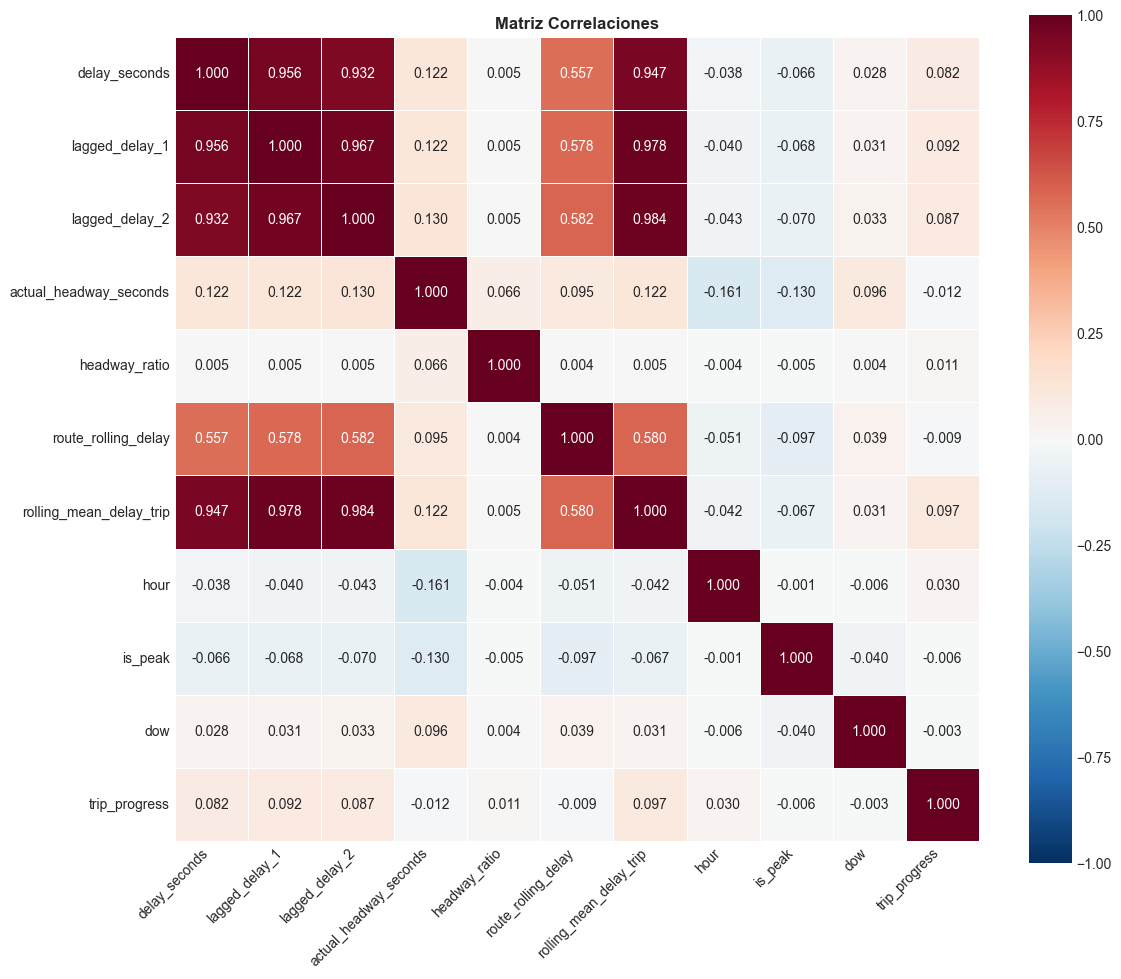

In [13]:
# Matriz de correlación
print("\n" + "="*70)
print("5.3 MATRIZ DE CORRELACIÓN")
print("="*70)

relevant_cols = [
    'delay_seconds', 'lagged_delay_1', 'lagged_delay_2',
    'actual_headway_seconds', 'headway_ratio',
    'route_rolling_delay', 'rolling_mean_delay_trip',
    'hour', 'is_peak', 'dow', 'trip_progress'
]

corr_matrix = df_full[relevant_cols].corr()
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0, 
            square=True, ax=ax, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('Matriz Correlaciones', fontweight='bold', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Sección 6: Headway


6.1 ANÁLISIS HEADWAY
count    7618413.00
mean         407.55
std          525.05
min            0.00
25%          155.00
50%          299.00
75%          529.00
max        85262.00
Name: actual_headway_seconds, dtype: float64


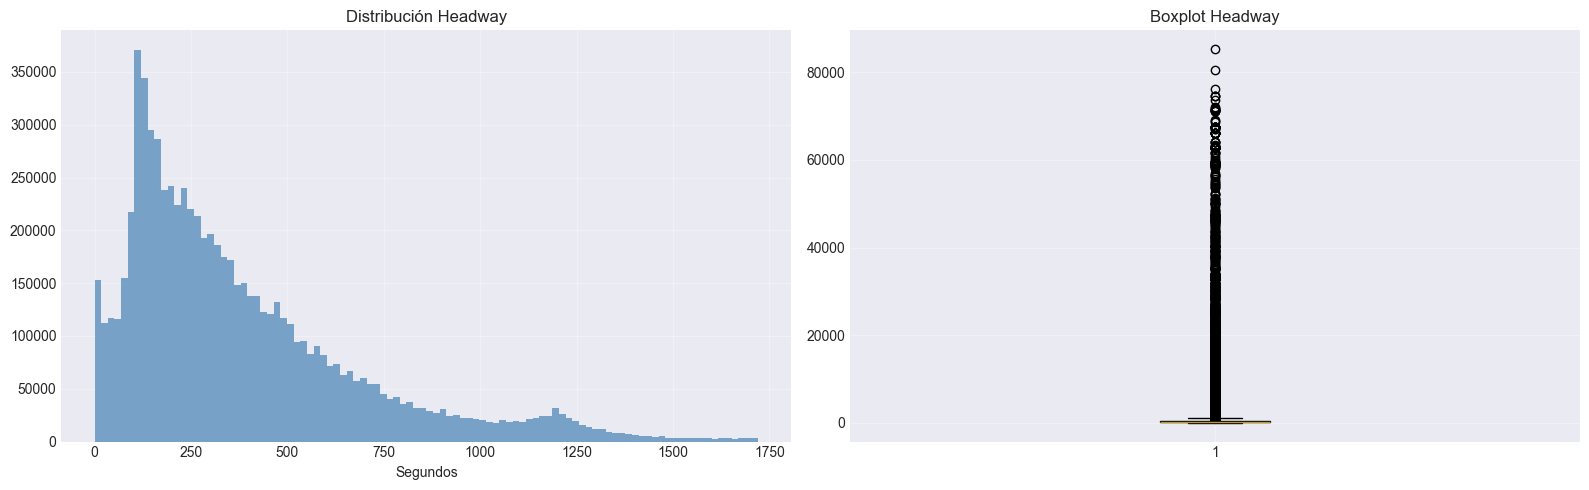

In [14]:
print("\n" + "="*70)
print("6.1 ANÁLISIS HEADWAY")
print("="*70)

print(df_full['actual_headway_seconds'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

headway_q99 = df_full['actual_headway_seconds'].quantile(0.99)
df_headway = df_full[df_full['actual_headway_seconds'] < headway_q99]

axes[0].hist(df_headway['actual_headway_seconds'].dropna(), bins=100, color='steelblue', alpha=0.7)
axes[0].set_title('Distribución Headway')
axes[0].set_xlabel('Segundos')
axes[0].grid(alpha=0.3)

bp = axes[1].boxplot(df_full['actual_headway_seconds'].dropna(), patch_artist=True)
for patch in bp['boxes']: patch.set_facecolor('lightgreen')
axes[1].set_title('Boxplot Headway')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


6.2 HEADWAY RATIO vs DELAY

Correlación: 0.0053

Delay por decil:
          mean     std   count
decile                        
0       118.36  405.34  566944
1        74.46  326.55  566958
2        58.09  292.35  566945
3        49.98  263.96  568091
4        44.93  239.06  565781
5        54.52  234.37  566969
6        73.47  270.52  566921
7        84.86  290.69  567023
8        91.69  305.95  566995
9       105.91  336.16  566810


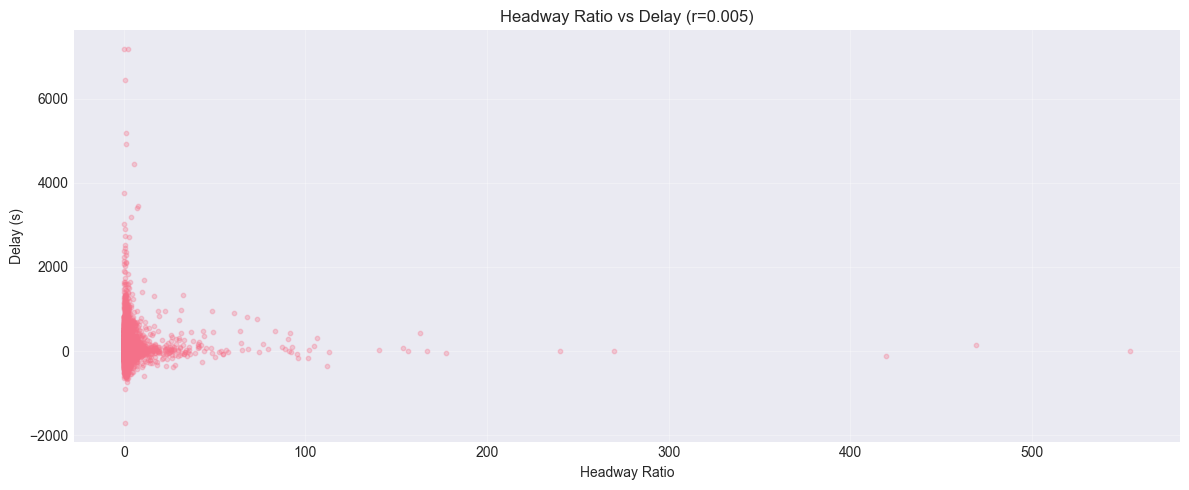

In [15]:
# 6.2 Headway ratio y delay (simplificado)
print("\n" + "="*70)
print("6.2 HEADWAY RATIO vs DELAY")
print("="*70)

headway_corr = df_full['delay_seconds'].corr(df_full['headway_ratio'])
print(f"\nCorrelación: {headway_corr:.4f}")

df_hw = df_full.dropna(subset=['delay_seconds', 'headway_ratio']).copy()
df_hw['decile'] = pd.qcut(df_hw['headway_ratio'], q=10, duplicates='drop', labels=False)
decile_stats = df_hw.groupby('decile')['delay_seconds'].agg(['mean', 'std', 'count']).round(2)
print("\nDelay por decil:")
print(decile_stats)

fig, ax = plt.subplots(figsize=(12, 5))
sample = df_hw.sample(min(10000, len(df_hw)))
ax.scatter(sample['headway_ratio'], sample['delay_seconds'], alpha=0.3, s=10)
ax.set_xlabel('Headway Ratio')
ax.set_ylabel('Delay (s)')
ax.set_title(f'Headway Ratio vs Delay (r={headway_corr:.3f})')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Sección 7: Trip Progress


7.1 TRIP PROGRESS
count     5815158.0
unique      14551.0
top             0.0
freq       212834.0
Name: trip_progress, dtype: float64

Correlación con delay: 0.0822

Delay por decil:
         count    mean     std
decile                        
0       572700   36.23  192.16
1       574214   32.33  197.73
2       571163   53.13  239.55
3       574498   66.90  264.12
4       570847   75.39  287.92
5       572788   83.43  307.61
6       573055  104.83  334.99
7       572548  119.20  358.50
8       573134  118.08  359.98
9       571812   77.61  397.35


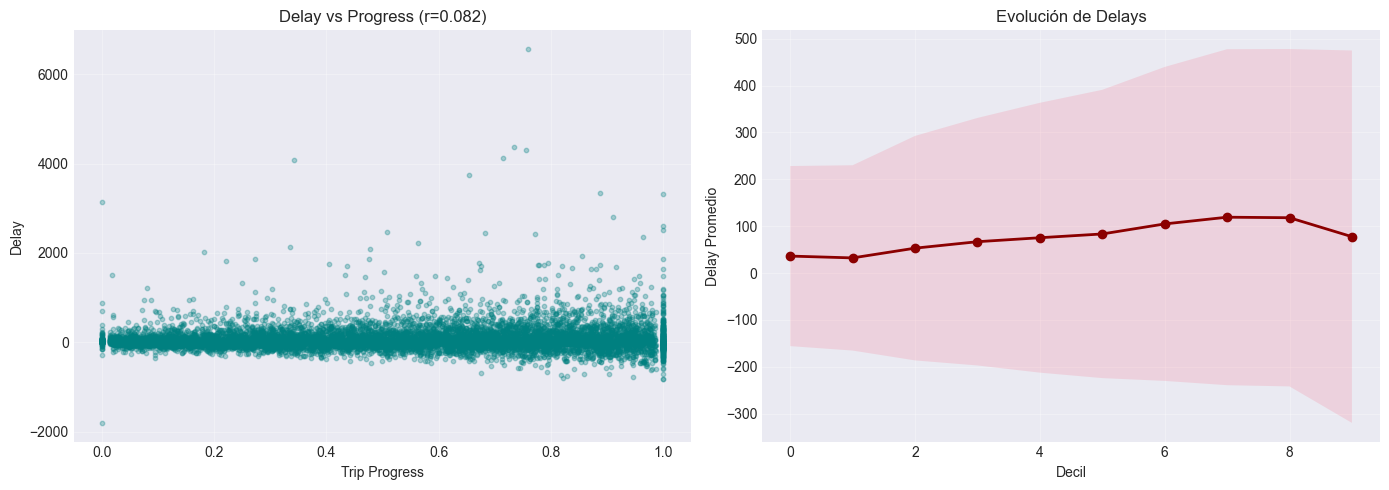

In [16]:
print("\n" + "="*70)
print("7.1 TRIP PROGRESS")
print("="*70)

print(df_full['trip_progress'].describe().round(3))
tp_corr = df_full['delay_seconds'].corr(df_full['trip_progress'])
print(f"\nCorrelación con delay: {tp_corr:.4f}")

df_tp = df_full.dropna(subset=['delay_seconds', 'trip_progress']).copy()
df_tp['decile'] = pd.qcut(df_tp['trip_progress'], q=10, duplicates='drop', labels=False)
tp_stats = df_tp.groupby('decile')['delay_seconds'].agg(['count', 'mean', 'std']).round(2)
print("\nDelay por decil:")
print(tp_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sample = df_tp.sample(min(10000, len(df_tp)))
axes[0].scatter(sample['trip_progress'], sample['delay_seconds'], alpha=0.3, s=10, color='teal')
axes[0].set_xlabel('Trip Progress')
axes[0].set_ylabel('Delay')
axes[0].set_title(f'Delay vs Progress (r={tp_corr:.3f})')
axes[0].grid(alpha=0.3)

tp_mean = df_tp.groupby('decile')['delay_seconds'].mean()
axes[1].plot(tp_mean.index, tp_mean.values, marker='o', linewidth=2, color='darkred')
axes[1].fill_between(tp_mean.index, tp_mean.values - df_tp.groupby('decile')['delay_seconds'].std().values,
                      tp_mean.values + df_tp.groupby('decile')['delay_seconds'].std().values, alpha=0.2)
axes[1].set_xlabel('Decil')
axes[1].set_ylabel('Delay Promedio')
axes[1].set_title('Evolución de Delays')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Sección 7.2: Feature Importance


7.2 FEATURE IMPORTANCE (RANDOM FOREST)

Entrenando Random Forest...

Top 10 Features:
                Feature  Importance
         lagged_delay_1    0.729213
rolling_mean_delay_trip    0.248841
          trip_progress    0.015191
          route_encoded    0.003566
         lagged_delay_2    0.001605
    route_rolling_delay    0.001065
 actual_headway_seconds    0.000278
                   hour    0.000082
         period_encoded    0.000063
          headway_ratio    0.000046


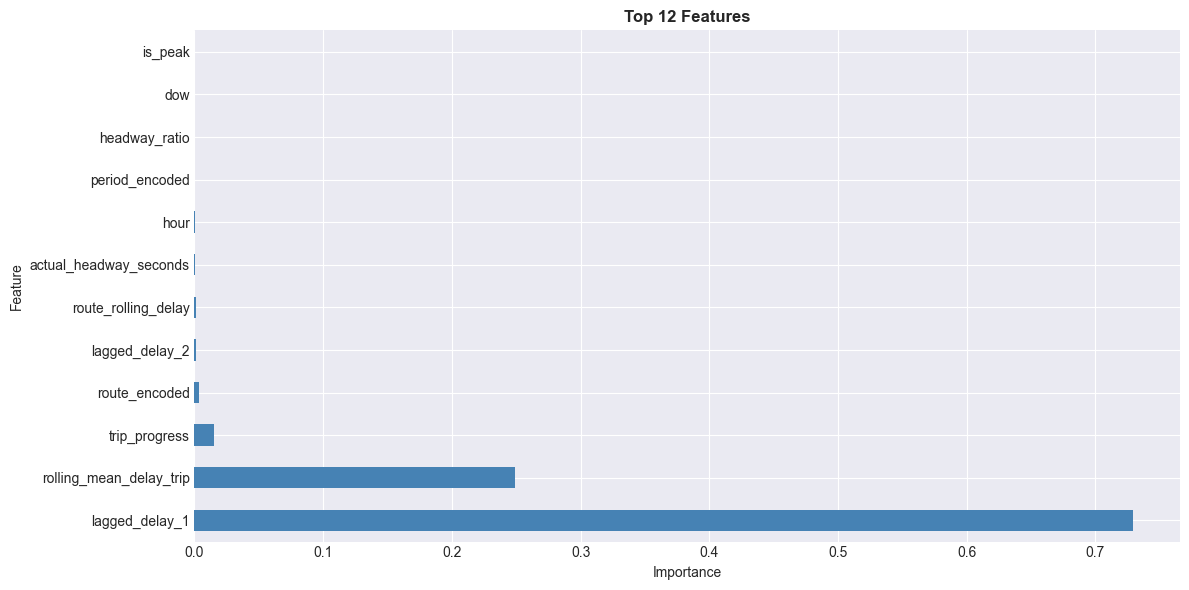


R² Score: 0.9057


In [17]:
print("\n" + "="*70)
print("7.2 FEATURE IMPORTANCE (RANDOM FOREST)")
print("="*70)

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

df_ml = df_full.copy()
feature_cols = ['hour', 'dow', 'is_peak', 'is_weekend',
                'lagged_delay_1', 'lagged_delay_2',
                'actual_headway_seconds', 'headway_ratio',
                'route_rolling_delay', 'rolling_mean_delay_trip', 'trip_progress']

le_route = LabelEncoder()
le_period = LabelEncoder()
df_ml['route_encoded'] = le_route.fit_transform(df_ml['route_id'].astype(str))
df_ml['period_encoded'] = le_period.fit_transform(df_ml['period_of_day'].fillna('unknown'))
feature_cols += ['route_encoded', 'period_encoded']

X = df_ml[feature_cols].fillna(0)
y = df_ml['delay_seconds'].fillna(0)

print("\nEntrenando Random Forest...")
rf = RandomForestRegressor(n_estimators=20, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Features:")
print(importance_df.head(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 6))
importance_df.head(12).plot(x='Feature', y='Importance', kind='barh', ax=ax, legend=False, color='steelblue')
ax.set_title('Top 12 Features', fontweight='bold', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

r2 = rf.score(X, y)
print(f"\nR² Score: {r2:.4f}")

## Sección 8: Unscheduled Trains


8.1 UNSCHEDULED POR HORA

Porcentaje UNSCHEDULED por hora:
  00:00 - 68,388 / 173,866 =  39.33%
  01:00 - 59,579 / 144,418 =  41.25%
  02:00 - 45,090 / 135,484 =  33.28%
  03:00 - 37,564 / 135,143 =  27.80%
  04:00 - 33,904 / 140,038 =  24.21%
  05:00 - 35,226 / 177,566 =  19.84%
  06:00 - 57,207 / 277,190 =  20.64%
  07:00 - 84,325 / 383,631 =  21.98%
  08:00 - 100,875 / 442,838 =  22.78%
  09:00 - 101,916 / 435,715 =  23.39%
  10:00 - 94,973 / 397,819 =  23.87%
  11:00 - 92,269 / 385,681 =  23.92%
  12:00 - 92,937 / 382,365 =  24.31%
  13:00 - 91,760 / 383,924 =  23.90%
  14:00 - 89,973 / 386,538 =  23.28%
  15:00 - 89,878 / 402,179 =  22.35%
  16:00 - 97,288 / 436,933 =  22.27%
  17:00 - 107,709 / 451,635 =  23.85%
  18:00 - 111,070 / 436,152 =  25.47%
  19:00 - 105,565 / 412,424 =  25.60%
  20:00 - 96,227 / 381,787 =  25.20%
  21:00 - 89,282 / 337,400 =  26.46%
  22:00 - 80,087 / 279,465 =  28.66%
  23:00 - 66,109 / 224,200 =  29.49%


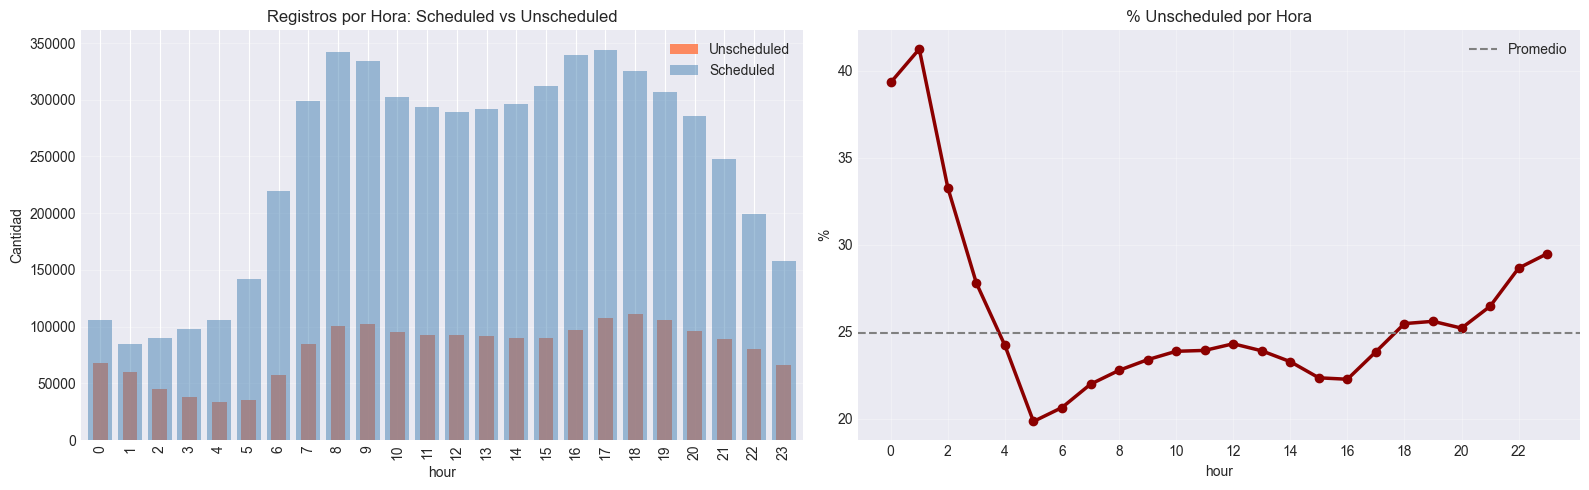

In [18]:
print("\n" + "="*70)
print("8.1 UNSCHEDULED POR HORA")
print("="*70)

df_u = df_full[df_full['dataset_type'] == 'unscheduled']
df_s = df_full[df_full['dataset_type'] == 'scheduled']

unsched_h = df_u.groupby('hour').size()
sched_h = df_s.groupby('hour').size()
total_h = df_full.groupby('hour').size()
unsched_pct_h = (unsched_h / total_h * 100).fillna(0)

print(f"\nPorcentaje UNSCHEDULED por hora:")
for h in range(24):
    u_count = unsched_h.get(h, 0)
    t_count = total_h.get(h, 0)
    pct = unsched_pct_h.get(h, 0)
    print(f"  {h:02d}:00 - {u_count:>6,} / {t_count:>7,} = {pct:>6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

unsched_h.plot(kind='bar', ax=axes[0], color='coral', alpha=0.9, label='Unscheduled')
sched_h.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.5, label='Scheduled', width=0.8)
axes[0].set_title('Registros por Hora: Scheduled vs Unscheduled')
axes[0].set_ylabel('Cantidad')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

unsched_pct_h.plot(kind='line', ax=axes[1], marker='o', linewidth=2.5, color='darkred')
axes[1].axhline(y=df_u.shape[0] / df_full.shape[0] * 100, color='gray', linestyle='--', label='Promedio')
axes[1].set_title('% Unscheduled por Hora')
axes[1].set_ylabel('%')
axes[1].set_xticks(range(0, 24, 2))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


8.2 UNSCHEDULED POR DÍA Y RUTA

Porcentaje UNSCHEDULED por día:
  Lunes     : 295,526 / 1,301,440 =  22.71%
  Martes    : 318,686 / 1,389,891 =  22.93%
  Miércoles : 271,688 / 1,146,885 =  23.69%
  Jueves    : 273,895 / 1,145,044 =  23.92%
  Viernes   : 259,251 / 1,162,105 =  22.31%
  Sábado    : 245,728 / 755,962 =  32.51%
  Domingo   : 264,427 / 843,064 =  31.36%


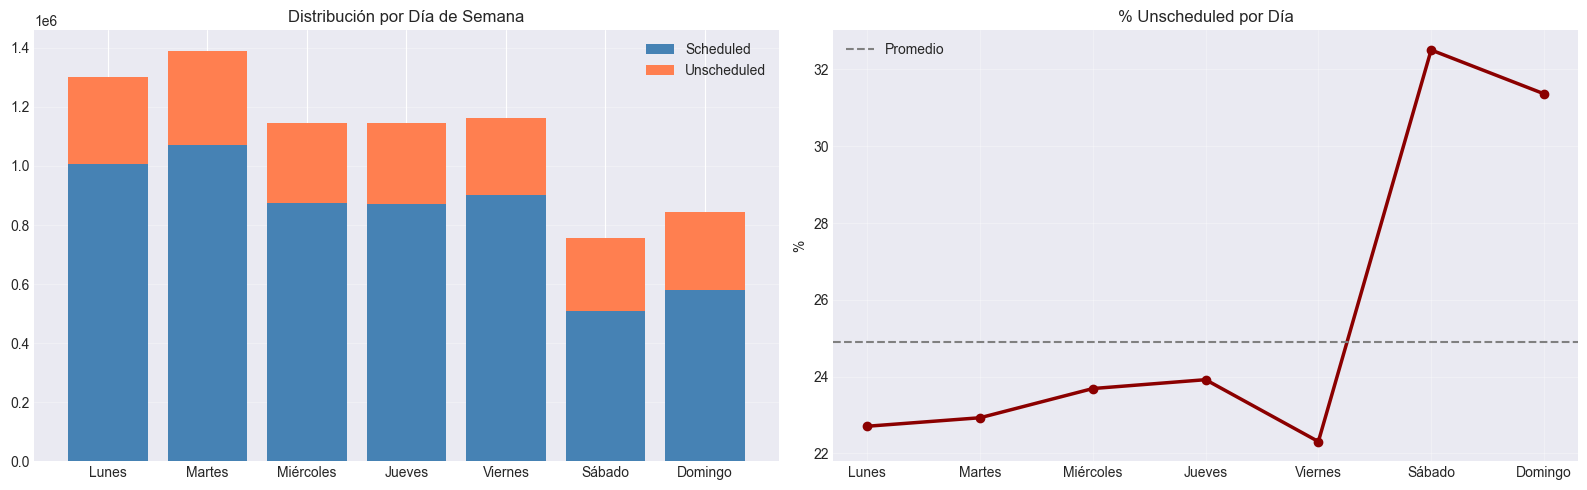


>>> Top 5 rutas con más UNSCHEDULED:

Resumen Unscheduled: 24.91% del total


In [19]:
print("\n" + "="*70)
print("8.2 UNSCHEDULED POR DÍA Y RUTA")
print("="*70)

dow_names = {0: 'Lunes', 1: 'Martes', 2: 'Miércoles', 3: 'Jueves', 4: 'Viernes', 5: 'Sábado', 6: 'Domingo'}

unsched_d = df_u.groupby('dow').size()
sched_d = df_s.groupby('dow').size()
total_d = df_full.groupby('dow').size()
unsched_pct_d = (unsched_d / total_d * 100).fillna(0)

print(f"\nPorcentaje UNSCHEDULED por día:")
for d in range(7):
    u_count = unsched_d.get(d, 0)
    t_count = total_d.get(d, 0)
    pct = unsched_pct_d.get(d, 0)
    day = dow_names[d]
    print(f"  {day:10s}: {u_count:>6,} / {t_count:>7,} = {pct:>6.2f}%")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

dow_order = [dow_names[i] for i in range(7)]
u_counts = [unsched_d.get(i, 0) for i in range(7)]
s_counts = [sched_d.get(i, 0) for i in range(7)]
x = np.arange(len(dow_order))

axes[0].bar(x, s_counts, label='Scheduled', color='steelblue')
axes[0].bar(x, u_counts, bottom=s_counts, label='Unscheduled', color='coral')
axes[0].set_title('Distribución por Día de Semana')
axes[0].set_xticks(x)
axes[0].set_xticklabels(dow_order)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

u_pct_plot = [unsched_pct_d.get(i, 0) for i in range(7)]
axes[1].plot(dow_order, u_pct_plot, marker='o', linewidth=2.5, color='darkred')
axes[1].axhline(y=df_u.shape[0] / df_full.shape[0] * 100, color='gray', linestyle='--', label='Promedio')
axes[1].set_title('% Unscheduled por Día')
axes[1].set_ylabel('%')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n>>> Top 5 rutas con más UNSCHEDULED:")
top_routes_u = df_u['route_id'].value_counts().head(5)
for route, count in top_routes_u.items():
    total = len(df_full[df_full['route_id'] == route])
    pct = count / total * 100 if total > 0 else 0
    print(f"  {route}: {count:>6,} / {total:>7,} = {pct:>6.2f}%")

print(f"\nResumen Unscheduled: {df_u.shape[0]/df_full.shape[0]*100:.2f}% del total")

## Sección 9: Predicción a Largo Plazo

### 9.1 Decaimiento de la autocorrelación
Se calcula la correlación de Pearson entre el retraso actual (`delay_seconds`) 
y distintos horizontes temporales (`delay_seconds`, `target_delay_10m`,
`target_delay_20m`, `target_delay_30m`) para visualizar cómo cae la
autocorrelación con el horizonte.

                  pearson_corr
delay_seconds         1.000000
target_delay_10m      0.859060
target_delay_20m      0.753208
target_delay_30m      0.648836


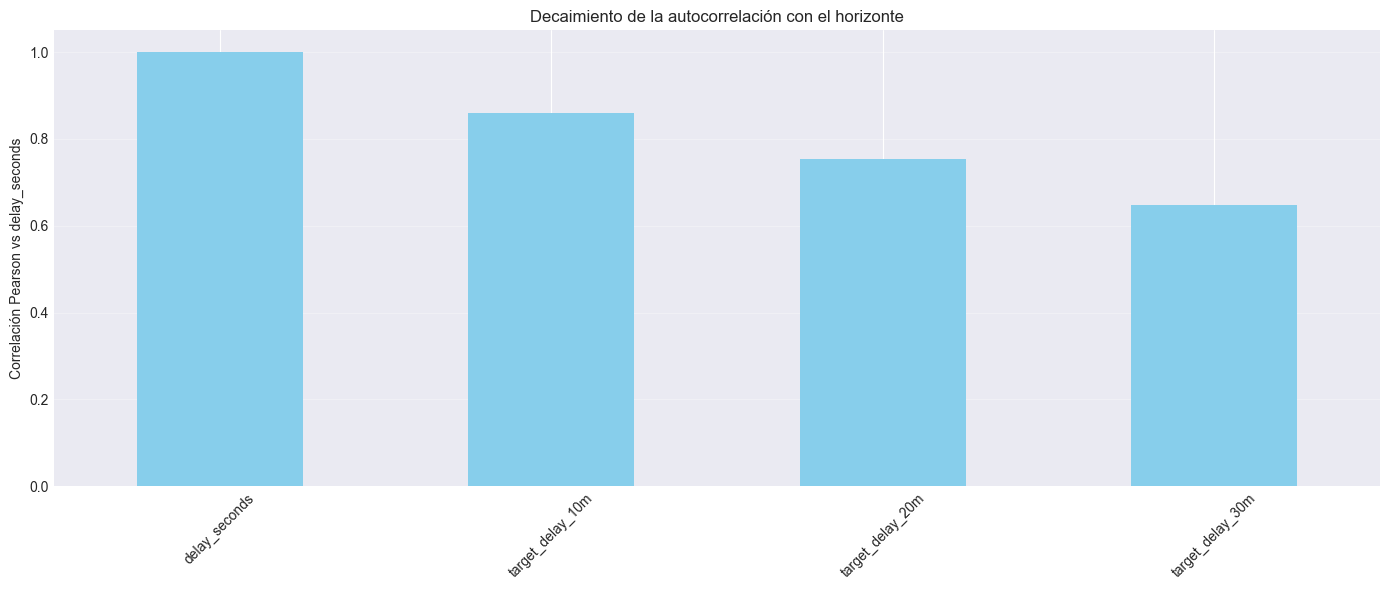

In [20]:
horizons = ['delay_seconds', 'target_delay_10m',
            'target_delay_20m', 'target_delay_30m']
corr_vals = {h: df_full['delay_seconds'].corr(df_full[h]) for h in horizons}

corr_df = pd.DataFrame.from_dict(corr_vals, orient='index',
                                 columns=['pearson_corr'])
print(corr_df)

# plot
corr_df.plot(kind='bar', legend=False, color='skyblue')
plt.title('Decaimiento de la autocorrelación con el horizonte')
plt.ylabel('Correlación Pearson vs delay_seconds')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 9.2 Cambio de Importancia de Variables (Feature Shift)

Correlaciones de las entradas `lagged_delay_1`, `route_rolling_delay`,
`trip_progress` e `is_peak` frente a dos objetivos:
- corto plazo: `delay_seconds`
- largo plazo: `target_delay_30m`

                  mean  median     std     min     max
delta_delay_10m  13.19     0.0  161.02 -7734.0  8974.0
delta_delay_20m  28.70    10.0  214.61 -7719.0  9030.0
delta_delay_30m  42.39    19.0  258.40 -8019.0  8996.0


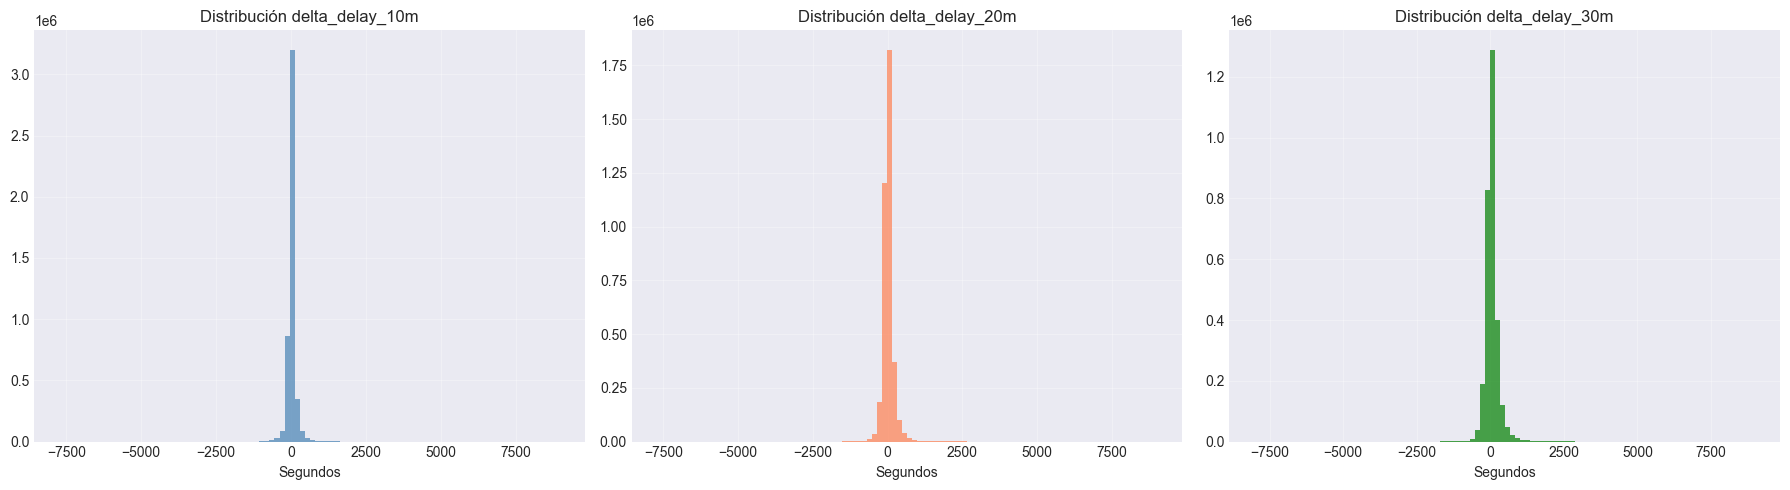


Correlaciones entre deltas:
                 delta_delay_10m  delta_delay_20m  delta_delay_30m
delta_delay_10m            1.000            0.654            0.543
delta_delay_20m            0.654            1.000            0.771
delta_delay_30m            0.543            0.771            1.000


In [21]:
# 9.2 – análisis de deltas por horizonte
delta_cols = ['delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m']
delta_stats = pd.DataFrame(index=delta_cols, columns=['mean', 'median', 'std', 'min', 'max'], dtype=float)

for delta in delta_cols:
    delta_stats.loc[delta, 'mean'] = df_full[delta].mean()
    delta_stats.loc[delta, 'median'] = df_full[delta].median()
    delta_stats.loc[delta, 'std'] = df_full[delta].std()
    delta_stats.loc[delta, 'min'] = df_full[delta].min()
    delta_stats.loc[delta, 'max'] = df_full[delta].max()

print(delta_stats.round(2))

# Comparación de distribuciones
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, delta in enumerate(delta_cols):
    axes[idx].hist(df_full[delta].dropna(), bins=100, color=['steelblue', 'coral', 'green'][idx], alpha=0.7)
    axes[idx].set_title(f'Distribución {delta}')
    axes[idx].set_xlabel('Segundos')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlaciones entre deltas
print(f'\nCorrelaciones entre deltas:')
print(df_full[delta_cols].corr().round(3))

### 9.3 Análisis de Bola de Nieve por Franja Horaria

Filtramos registros con `delay_seconds` entre 120 y 300 s, agrupamos por
`period_of_day` y comparamos la media del retraso actual frente al
`target_delay_30m`. El gráfico de barras agrupadas muestra en qué periodos
los trenes recuperan o empeoran tiempo.

               delay_seconds  target_delay_30m
period_of_day                                 
evening_peak      191.596900        245.651127
midday            193.996819        234.876221
morning_peak      190.575619        213.186412
off_peak          195.848019        274.655041


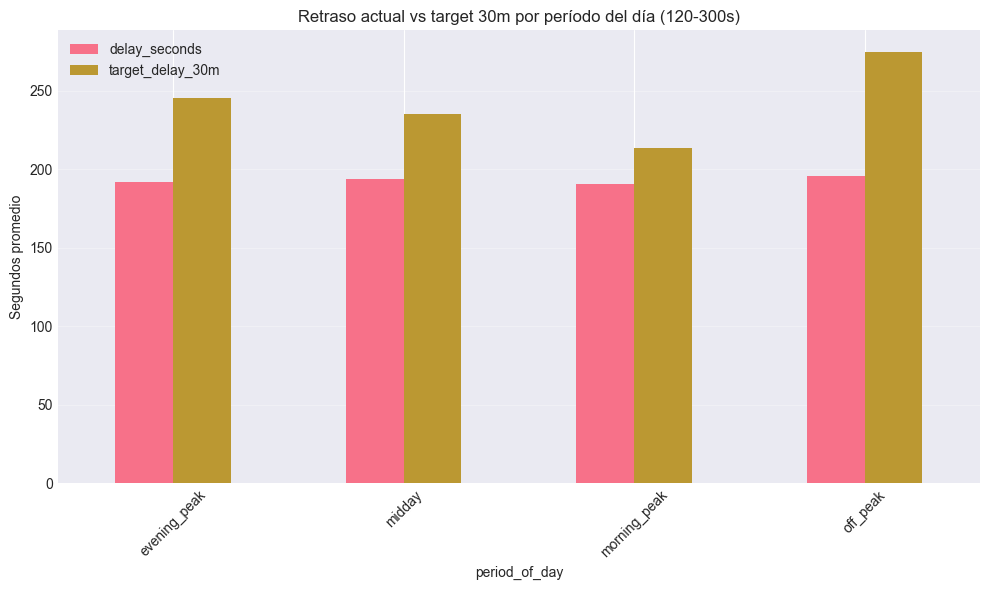

In [22]:
# 9.3 – bola de nieve por periodo del día
subset = df_full[(df_full['delay_seconds'] >= 120) &
                 (df_full['delay_seconds'] <= 300)].copy()

period_stats = subset.groupby('period_of_day')[['delay_seconds',
                                               'target_delay_30m']].mean()
print(period_stats)

period_stats.plot(kind='bar', figsize=(10,6))
plt.title('Retraso actual vs target 30m por período del día (120-300s)')
plt.ylabel('Segundos promedio')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Sección 10: Capacidad de Recuperación

### 10.1 Delta de retraso a 30 min y salud de la línea
Se crea una columna temporal `delta_delay_30m` para medir cuánto se espera
que cambie el retraso en 30 minutos. A continuación se explora la relación
entre esta cantidad y el `route_rolling_delay` (salud de la línea) y se
calcula la media por franja horaria.

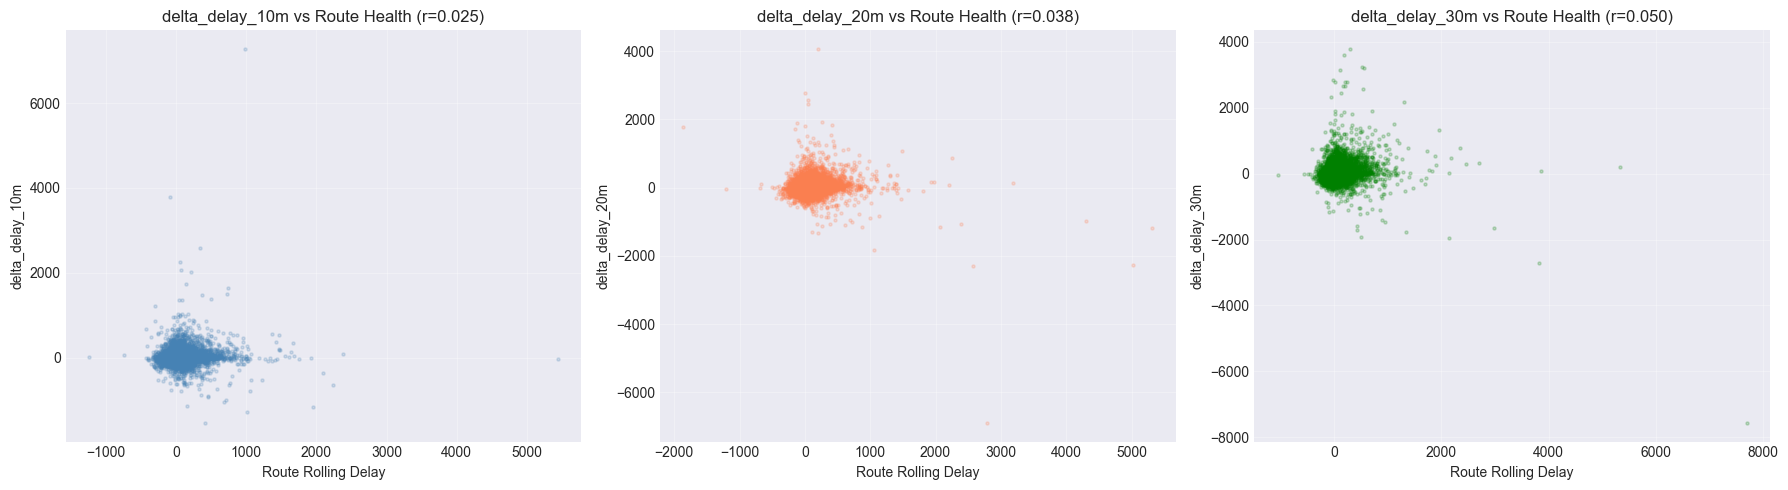


MEDIA DE DELTAS POR PERÍODO DEL DÍA

delta_delay_10m:
period_of_day
off_peak        17.30
morning_peak     6.73
midday          12.14
evening_peak    15.88
Name: delta_delay_10m, dtype: float64

delta_delay_20m:
period_of_day
off_peak        37.91
morning_peak    14.86
midday          26.88
evening_peak    33.57
Name: delta_delay_20m, dtype: float64

delta_delay_30m:
period_of_day
off_peak        57.89
morning_peak    20.89
midday          39.08
evening_peak    49.05
Name: delta_delay_30m, dtype: float64


In [23]:
# 10.1 – análisis de deltas y salud de línea
delta_cols = ['delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m']

# Scatter plots: salud de línea vs deltas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors_delta = ['steelblue', 'coral', 'green']

for idx, delta in enumerate(delta_cols):
    sample = df_full.dropna(subset=[delta, 'route_rolling_delay']).sample(min(10000, len(df_full)))
    axes[idx].scatter(sample['route_rolling_delay'], sample[delta], alpha=0.2, s=5, color=colors_delta[idx])
    axes[idx].set_xlabel('Route Rolling Delay')
    axes[idx].set_ylabel(delta)
    corr_val = df_full['route_rolling_delay'].corr(df_full[delta])
    axes[idx].set_title(f'{delta} vs Route Health (r={corr_val:.3f})')
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas por período del día
print("\n" + "="*70)
print("MEDIA DE DELTAS POR PERÍODO DEL DÍA")
print("="*70)

period_order = ['off_peak', 'morning_peak', 'midday', 'evening_peak']
for delta in delta_cols:
    delta_period = df_full.groupby('period_of_day')[delta].mean().reindex(period_order)
    print(f'\n{delta}:')
    print(delta_period.round(2))

### 10.2 Líneas que absorben mejor los retrasos
Nos quedamos con trenes que ya tienen un retraso importante
(`delay_seconds > 180`) y calculamos la media de `target_delay_end` por
`route_id`. Un gráfico de barras horizontal ordenado muestra qué líneas
terminan más retrasadas y cuáles reducen el retraso.

route_id
J     221.873271
Z     235.021293
C     257.859477
F     270.591971
GS    281.285714
Name: target_delay_end, dtype: float64


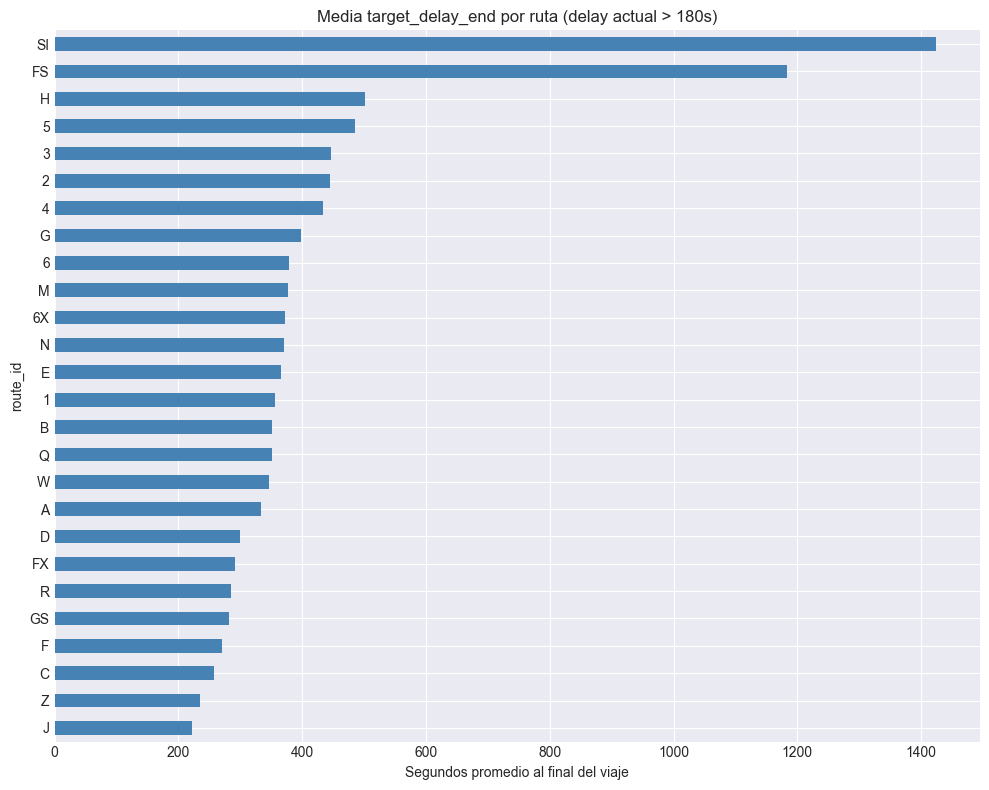

In [24]:
# 10.2 – retraso final por línea para trenes retrasados actualmente
late = df_full[df_full['delay_seconds'] > 180].copy()
route_end = late.groupby('route_id')['target_delay_end'].mean().sort_values()
print(route_end.head())  # mostrar primeras líneas como sanity check

# grafico horizontal
plt.figure(figsize=(10,8))
route_end.plot(kind='barh', color='steelblue')
plt.title('Media target_delay_end por ruta (delay actual > 180s)')
plt.xlabel('Segundos promedio al final del viaje')
plt.ylabel('route_id')
plt.tight_layout()
plt.show()

### 10.3 Impacto de la distancia en el retraso final
Agrupamos por `stops_to_end` y calculamos la mediana y el percentil 90 de
`target_delay_end`. Dos líneas superpuestas permiten ver cómo varían la
mediana y el P90 a medida que nos acercamos al destino.

              mediana    p90
stops_to_end                
0                -7.0  385.0
1                -7.0  385.0
2                 0.0  408.0
3                 0.0  408.0
4                 2.0  410.0


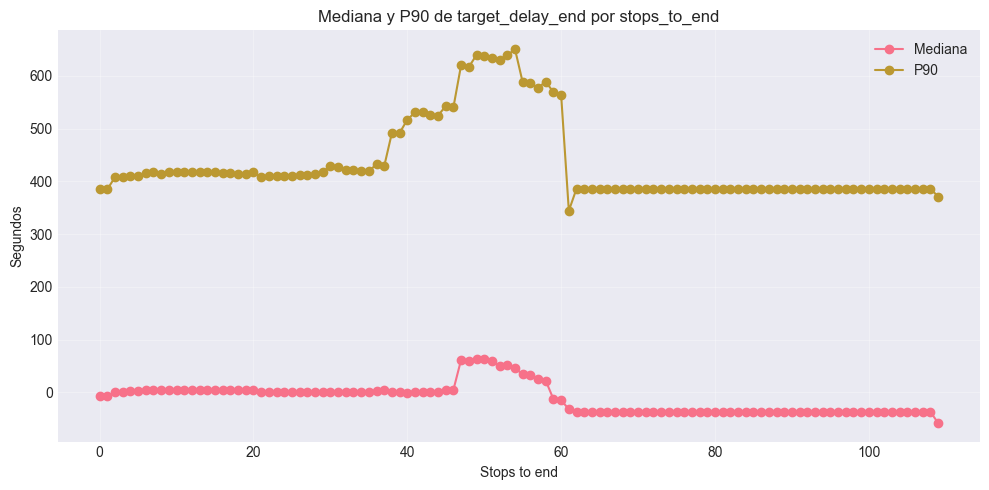

In [25]:
# 10.3 – bivariado distance vs retraso final
agg = df_full.groupby('stops_to_end')['target_delay_end'].agg(
    mediana='median', p90=lambda x: x.quantile(0.90)
)
print(agg.head())

plt.figure(figsize=(10,5))
plt.plot(agg.index, agg['mediana'], label='Mediana', marker='o')
plt.plot(agg.index, agg['p90'], label='P90', marker='o')
plt.title('Mediana y P90 de target_delay_end por stops_to_end')
plt.xlabel('Stops to end')
plt.ylabel('Segundos')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
s = df_full['stop_id'].astype(str).str.strip()
suffix = s.str.extract(r'([NS])$', expand=False)
counts = suffix.value_counts(dropna=False)
props = suffix.value_counts(normalize=True, dropna=False)

print("Counts:\n", counts)
print("\nProportions:\n", props)

Counts:
 stop_id
S    3891814
N    3852577
Name: count, dtype: int64

Proportions:
 stop_id
S    0.502533
N    0.497467
Name: proportion, dtype: float64


In [27]:
stops = s.drop_duplicates()
m = stops.str.extract(r'^(?P<base>\d+)(?P<dir>[NS])$').dropna()

present = (m.drop_duplicates()
            .assign(present=True)
            .pivot(index='base', columns='dir', values='present')
            .fillna(False))

only_n = present[present.get('N', False) & ~present.get('S', False)]
only_s = present[present.get('S', False) & ~present.get('N', False)]

print("Bases total:", len(present))
print("Solo N:", len(only_n))
print("Solo S:", len(only_s))

Bases total: 178
Solo N: 1
Solo S: 1


### 10.4 Importancia de características empírica para 10, 20, 30 min
Se entrena un RandomForestRegressor ligero para predecir los
`target_delay` y se visualizan las importancias de las variables
seleccionadas.


delta_delay_10m:
               feature  importance
               is_peak    0.000674
actual_headway_seconds    0.133291
                  hour    0.138934
         delay_seconds    0.343821
   route_rolling_delay    0.383281


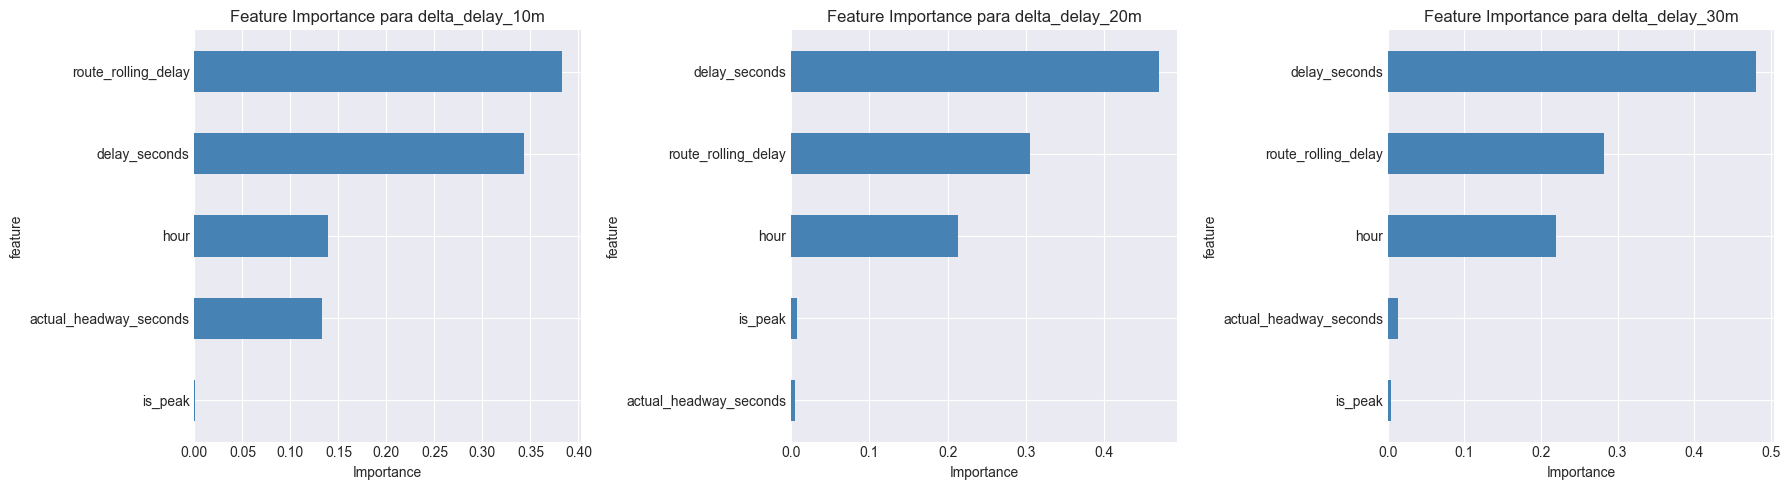

In [29]:
from sklearn.ensemble import RandomForestRegressor

# 10.4 – importancia de características para predicción de deltas
delta_cols = ['delta_delay_10m', 'delta_delay_20m', 'delta_delay_30m']
features = ['delay_seconds', 'route_rolling_delay', 
            'actual_headway_seconds', 'is_peak', 'hour']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, delta in enumerate(delta_cols):
    # preparar subset sin NaNs
    ml = df_full.dropna(subset=[delta]).copy()
    X = ml[features].fillna(0)
    y = ml[delta]
    
    # entrenar modelo ligero
    rf = RandomForestRegressor(n_estimators=30, max_depth=5,
                               random_state=42, n_jobs=-1)
    rf.fit(X, y)
    
    # extraer importancias
    imp = pd.DataFrame({'feature': features,
            'importance': rf.feature_importances_}).sort_values('importance', ascending=True)
    
    # graficar
    imp.plot(x='feature', y='importance', kind='barh', ax=axes[idx], legend=False, color='steelblue')
    axes[idx].set_title(f'Feature Importance para {delta}')
    axes[idx].set_xlabel('Importance')
    
    if idx == 0:
        print(f'\n{delta}:')
        print(imp.to_string(index=False))

plt.tight_layout()
plt.show()